In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from knn import KNN
import plotly.express as px

df = pd.read_csv('data/pokemon.csv', sep=';')
df['Type'] = df['Type'].astype('category').cat.codes
df['Type'] = df['Type'].astype('int')
df = df.rename(columns={'Attaque': 'attack', 'Points de vie': 'hp', 'Type': 'type', 'Nom': 'name'})

train, test = df.iloc[:30], df.iloc[30:]

train_y = train['type']
train_x = train.drop(columns=['type', 'name'])
test_y = test['type']
test_x = test.drop(columns=['type', 'name'])

display(df.describe(), df.head(), df.shape, df.dtypes)
display(train_x, train_y)

,hp,attack,type
count,34.000000,34.000000,34.000000
mean,72.941176,82.147059,0.529412
std,19.359347,41.132552,0.506640
min,45.000000,23.000000,0.000000
25%,56.000000,52.000000,0.000000
50%,73.000000,75.000000,1.000000
75%,83.750000,100.000000,1.000000
max,110.000000,190.000000,1.000000


,name,hp,attack,type
0,Ecayon,49,49,0
1,Tiplouf,53,51,0
2,Carabaffe,59,63,0
3,Prinplouf,64,66,0
4,Gobou,50,70,0


(34, 4)

name      object
hp         int64
attack     int64
type       int64
dtype: object

,hp,attack
0,49,49
1,53,51
2,59,63
3,64,66
4,50,70
5,71,73
6,75,75
7,90,75
8,65,80
9,80,80


0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    1
17    1
18    1
19    1
20    1
21    1
22    1
23    1
24    1
25    1
26    1
27    1
28    1
29    1
Name: type, dtype: int64

np.float64(0.5588235294117647)

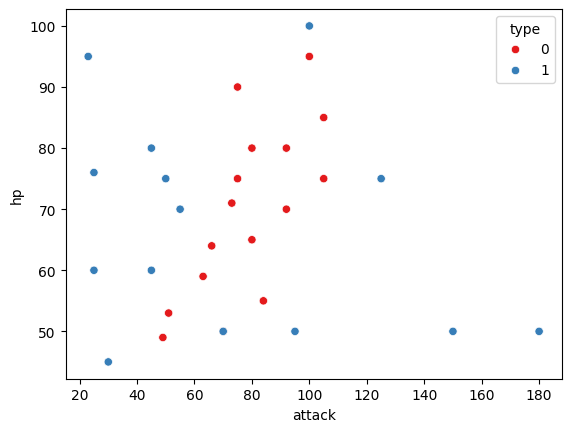

In [13]:
sns.scatterplot(data=train, x='attack', y='hp', hue='type', palette='Set1')

knn = KNN(k=7, distance='manhattan')
knn.fit(train_x.values, train_y.values)
predictions = knn.predict(test_x.values)

score = knn.score(df[['attack', 'hp']].values, df['type'].values)

score

In [14]:
fig = px.pie(
    df,
    values='attack',
    names='name',
    title='Attack Distribution by Pokémon',
    color_discrete_sequence=px.colors.sequential.RdBu,
)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(title_text='Attack Distribution by Pokémon', title_x=0.5)

fig.show()

In [15]:
# Visualize the type distribution

fig = px.pie(
    df,
    names='type',
    title='Type Distribution by Pokémon',
    color_discrete_sequence=px.colors.sequential.RdBu,
)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(title_text='Type Distribution by Pokémon', title_x=0.5)
fig.show()

In [16]:
# Visualize the type distribution, box plot
fig = px.box(
    df,
    x='type',
    y='attack',
    title='Attack Distribution by Pokémon Type',
    color='type',
    color_discrete_sequence=px.colors.sequential.RdBu,
)
fig.update_layout(title_text='Attack Distribution by Pokémon Type', title_x=0.5)
fig.show()

In [17]:
# Visualize the type distribution, box plot
fig = px.box(
    df,
    x='type',
    y='hp',
    title='Attack Distribution by Pokémon Type',
    color='type',
    color_discrete_sequence=px.colors.sequential.RdBu,
)
fig.update_layout(title_text='Attack Distribution by Pokémon Type', title_x=0.5)
fig.show()



In [18]:
fig = px.scatter(data_frame=df, x='attack', y='hp', color='type', size='attack',  hover_name='name', color_discrete_sequence=['#ffffd4', '#fe9929', '#993404'], template='plotly_dark',)

fig.show()

In [19]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['label'] = iris.target

X = df.drop("label", axis=1)
y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

knn = KNN(k=5, distance="minkowski", p=3, weighted=True)
knn.fit(X_train, y_train)
accuracy = knn.score(X_test, y_test)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 1.00
